In [ ]:
import jax
import flax
import optax
from jax import lax, random, value_and_grad,numpy as jnp
from jax import random, grad, vmap, hessian, jacfwd, jit
from jax import config
from flax import linen as nn
import jax_dataloader as jd

import time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colors

import os
from tqdm.auto import tqdm

#os.environ['CUDA_VISIBLE_DEVICES'] = '1'
config.update("jax_enable_x64", True)
os.environ['XLA_PYTHON_CLIENT_ALLOCATOR'] = 'cuda_async'
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'true' # default is true, 90% of GPU VRAM preallocated

In [20]:
DATA_DIR = Path.cwd().parent.parent / "data" / "poisson-gauss" / "snapshots"


Dataset summary:
<xarray.Dataset> Size: 3GB
Dimensions:   (sample: 20000, x: 128, y: 128)
Dimensions without coordinates: sample, x, y
Data variables:
    solution  (sample, x, y) float32 1GB ...
    source    (sample, x, y) float32 1GB ...

Extracted Source Shape: (128, 128)
Extracted Solution Shape: (128, 128)


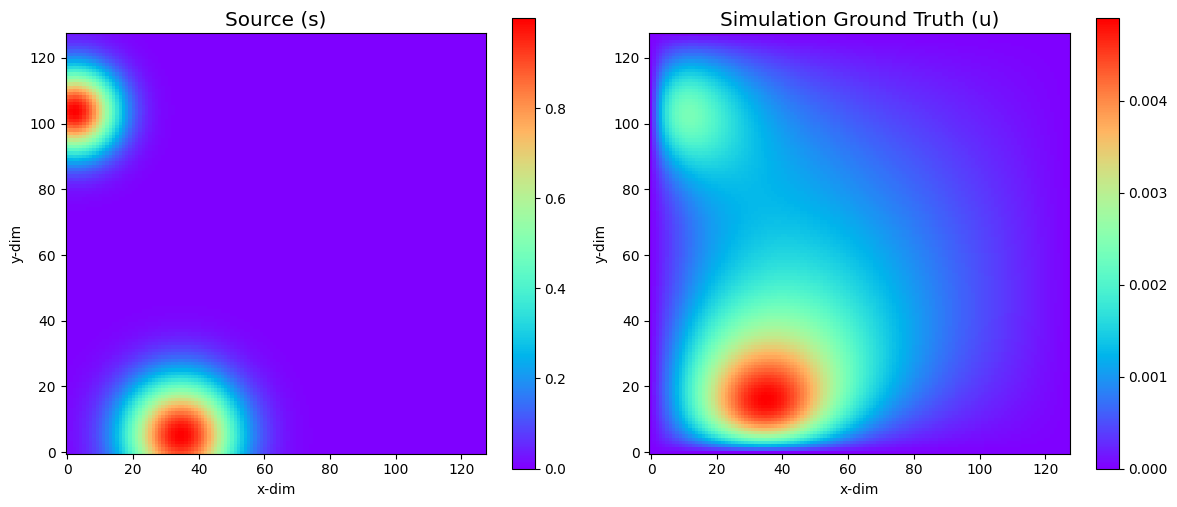

In [21]:
import xarray as xr

DATA_DIR = Path.cwd().parent.parent / "data" / "poisson-gauss" / "snapshots"
FILE_PATH = DATA_DIR / "Poisson-Gauss.nc" 

ds = xr.open_dataset(FILE_PATH)
print(f"Dataset summary:\n{ds}\n")

sample_idx = 0
source_sample = ds['source'][sample_idx].values
solution_sample = ds['solution'][sample_idx].values

print(f"Extracted Source Shape: {source_sample.shape}")
print(f"Extracted Solution Shape: {solution_sample.shape}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
im1 = axes[0].imshow(source_sample, origin='lower', cmap='rainbow')
fig.colorbar(im1, ax=axes[0])
axes[0].set_title('Source (s)', fontsize='x-large')
axes[0].set_xlabel('x-dim')
axes[0].set_ylabel('y-dim')
im2 = axes[1].imshow(solution_sample, origin='lower', cmap='rainbow')
fig.colorbar(im2, ax=axes[1])
axes[1].set_title('Simulation Ground Truth (u)', fontsize='x-large')
axes[1].set_xlabel('x-dim')
axes[1].set_ylabel('y-dim')
plt.tight_layout()
plt.show()

ds.close()

In [ ]:
nx, ny = source_sample.shape # 128, 128

x_coords = np.arange(nx)
y_coords = np.arange(ny)
X, Y = np.meshgrid(x_coords, y_coords, indexing='ij') # 0 to 127

x = jnp.array(X.reshape(-1, 1))
y = jnp.array(Y.reshape(-1, 1))
s = jnp.array(source_sample.reshape(-1, 1))
u_sim = jnp.array(solution_sample.reshape(-1, 1))

# Dirichlet Boundary Condition
x_l, x_u = 0, nx - 1
y_l, y_u = 0, ny - 1

bc_left = (x == x_l).flatten() # Array([ True,  True,  True, ..., False, False, False], dtype=bool)
bc_right = (x == x_u).flatten()
bc_bottom = (y == y_l).flatten()
bc_top = (y == y_u).flatten()

bc_all = bc_left | bc_right | bc_bottom | bc_top # an array of True if on boundary, False if not on boundary.

# Extract only boundary coordinates
x_bc = x[bc_all]
y_bc = y[bc_all]

u_bc = jnp.zeros_like(x_bc) # Dirichlet u=0


E0527 20:57:06.006404   71446 cuda_executor.cc:1526] Could not get kernel mode driver version: (INVALID_ARGUMENT: Version does not match the format X.Y.Z)
E0527 20:57:06.083503   25683 cuda_executor.cc:1526] Could not get kernel mode driver version: (INVALID_ARGUMENT: Version does not match the format X.Y.Z)


In [ ]:
class FeatureExtractor(nn.Module):
    hidden_layers: list
    out_features: int # m (no. of columns)
    
    @nn.compact
    def __call__(self, x_in, y_in):
        # Min-Max Normalization to [-1, 1], hard coded for 0 to 127 gridsize
        x_norm = 2.0 * (jnp.squeeze(x_in) / 127.0) - 1.0
        y_norm = 2.0 * (jnp.squeeze(y_in) / 127.0) - 1.0
        
        # Combine into one vector
        h = jnp.stack([x_norm, y_norm])
        
        for size in self.hidden_layers:
            h = nn.Dense(size, kernel_init=nn.initializers.he_normal())(h)
            h = nn.tanh(h) 
            
        features = nn.Dense(self.out_features, kernel_init=nn.initializers.he_normal())(h)
        return features

model = FeatureExtractor(hidden_layers=[50, 50, 50], out_features=150) # future: can use optuna to find best hyperparams

# Dummy initialization to get the shapes right
key = jax.random.PRNGKey(0)
dummy_x, dummy_y = jnp.array([0.0]), jnp.array([0.0])
params = model.init(key, dummy_x, dummy_y)

def get_f(params, x_val, y_val):
    return model.apply(params, x_val, y_val)

def get_f_dir(params, x_val, y_val):
    f = get_f(params, x_val, y_val)
    
    f_x = jacfwd(get_f, argnums=1)(params, x_val, y_val)
    f_y = jacfwd(get_f, argnums=2)(params, x_val, y_val)
    
    f_xx = jacfwd(jacfwd(get_f, argnums=1), argnums=1)(params, x_val, y_val)
    f_yy = jacfwd(jacfwd(get_f, argnums=2), argnums=2)(params, x_val, y_val)
    
    return f, f_x, f_y, f_xx, f_yy

# VMAP over the batch dimension (axis 0 for x and y, None for params)
f_vmap = vmap(get_f, in_axes=(None, 0, 0))
f_dir_vmap = vmap(get_f_dir, in_axes=(None, 0, 0))

In [ ]:
optimizer = optax.adam(learning_rate=1e-3)
opt_state = optimizer.init(params)

# Initialize the final linear weights (w) to zeros
# Size M=150 to match out_features of the FeatureExtractor
M = 150
w = jnp.zeros((M, 1))

# freeze final linear layer weights
def compute_loss(params, w_current, x_batch, y_batch, s_batch, x_bc, y_bc, u_bc):
    _, _, _, f_xx, f_yy = f_dir_vmap(params, x_batch, y_batch)
    
    u_xx = jnp.dot(f_xx, w_current)
    u_yy = jnp.dot(f_yy, w_current)
    laplacian_u = u_xx + u_yy
    
    pde_residual = laplacian_u - s_batch
    loss_pde = jnp.mean(pde_residual ** 2)
    
    # Boundary Condition Loss (Dirichlet u = 0) 
    f_bc_vals = f_vmap(params, x_bc, y_bc)
    u_bc_pred = jnp.dot(f_bc_vals, w_current)
    loss_bc = jnp.mean((u_bc_pred - u_bc) ** 2)
    
    total_loss = loss_pde + loss_bc # Might need to add weighted values here later
    return total_loss

loss_grad_fn = jax.jit(value_and_grad(compute_loss, argnums=0))

In [ ]:
@jit
def kaczmarz_step(A_B, b_B, w_current, alpha): 
    block_size = A_B.shape[0]
    r = A_B @ w - b_B
    gram = A_B @ A_B.T + 1e-6 * jnp.eye(block_size)
    z = jnp.linalg.solve(gram, r)    
    w_new = w_current - alpha * (A_B.T @ z)
    return w_new

# try to find a way that does not even need to build the A matrix
@jit
def build_and_update_kaczmarz(params, w_current, x_batch, y_batch, s_batch, x_bc, y_bc, u_bc, alpha):
    """
    Builds the A and b matrices for the current batch and applies the Kaczmarz step.
    """
    _, _, _, f_xx, f_yy = f_dir_vmap(params, x_batch, y_batch)
    A_pde = f_xx + f_yy
    b_pde = s_batch
    
    A_bc = f_vmap(params, x_bc, y_bc)
    b_bc = u_bc
    
    A_block = jnp.vstack([A_pde, A_bc])
    b_block = jnp.vstack([b_pde, b_bc])
    
    w_updated = kaczmarz_step(A_block, b_block, w_current, alpha)
    return w_updated

In [ ]:
import optax
import jax

@jax.jit
def update_hidden(params, opt_state, w_current, x_batch, y_batch, s_batch, x_bc, y_bc, u_bc):
    """
    Takes a gradient descent step on the hidden weights (params) while freezing w.
    """
    loss, grads = loss_grad_fn(params, w_current, x_batch, y_batch, s_batch, x_bc, y_bc, u_bc)
    updates, opt_state = optimizer.update(grads, opt_state)
    new_params = optax.apply_updates(params, updates)
    
    return new_params, opt_state, loss

epochs = 100
batch_size = 4096
alpha = 1e-4     
total_points = x.shape[0]


rng = jax.random.PRNGKey(42)

for epoch in range(epochs):
    rng, shuffle_key = jax.random.split(rng)

    indices = jax.random.permutation(shuffle_key, total_points)
    
    epoch_loss = 0.0
    num_batches = 0
    
    for i in range(0, total_points, batch_size):
        batch_idx = indices[i : i + batch_size]
        
        x_batch = x[batch_idx]
        y_batch = y[batch_idx]
        s_batch = s[batch_idx]
        
        w = build_and_update_kaczmarz(params, w, x_batch, y_batch, s_batch, x_bc, y_bc, u_bc, alpha)
    
        params, opt_state, loss = update_hidden(params, opt_state, w, x_batch, y_batch, s_batch, x_bc, y_bc, u_bc)
        
        epoch_loss += loss
        num_batches += 1
        
    avg_loss = epoch_loss / num_batches
    
    if epoch % 10 == 0 or epoch == epochs - 1:
        f_all = f_vmap(params, x, y)
        u_pred = f_all @ w
        mse = jnp.mean((u_pred - u_sim)**2)
        
        print(f"Epoch {epoch:03d} | PDE/BC Loss: {avg_loss:.4e} | Full Grid MSE vs Ground Truth: {mse:.4e}")

print("Training Complete!")